**Import libraries and load dataset**

In [62]:
#Import basic libraries for data handling and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [63]:
!pip install gdown # reading file from g-drive
import gdown

In [64]:
!gdown --fuzzy "https://drive.google.com/file/d/1x62fsuPXQsWXdLvbqEtq5n-WCxDtME-0/view?usp=sharing"


Downloading...
From: https://drive.google.com/uc?id=1x62fsuPXQsWXdLvbqEtq5n-WCxDtME-0
To: /content/train.csv
100% 461k/461k [00:00<00:00, 103MB/s]


In [65]:
df = pd.read_csv("train.csv")

**Basic information of dataset**

In [66]:
# Get data overview (types, nulls, and summary)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [67]:
# Statistics of the DataFrame's numerical columns

df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Visualize missing values**

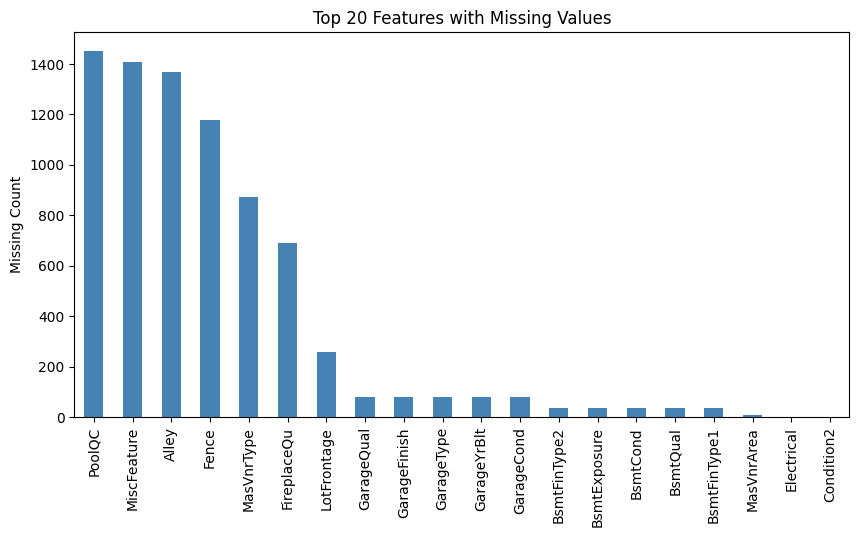

In [68]:
# Identify which columns have missing values to guide imputation decisions.

missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
missing[:20].plot(kind='bar', color='steelblue')
plt.title('Top 20 Features with Missing Values')
plt.ylabel('Missing Count')
plt.show()

**Handling missing values**

1. NaNs that mean "None" (Categorical)

   For these features, NaN means the item is not present. For example; No Pool, No Alley. Hence, fill them with the string "None" to make it a distinct category.

In [69]:
for col in ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
            'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']:
    df[col] = df[col].fillna('None')

2. NaN that mean O (Numeric)

   For these numeric features, NaN means 0. For example, 0 Garage Cars

In [70]:
for col in ['MasVnrArea', 'GarageYrBlt', 'GarageCars', 'GarageArea']:
    df[col] = df[col].fillna(0)

3. Fill NaNs with Mode (True Missing)

   For 'Electrical', there is only one missing value. So using Mode (Most frequent) is appropriate in this case.

In [71]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

4. Fill 'LotFrontage' with Neighbourhood Median

   LotFrontage (linear feet of street) is mostly similar for houses in the same neighborhood. Thus, we fill missing values with median LotFrontage of their Neighbourhood


In [72]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

In [73]:
# Check if any nulls remain

print("Missing values remaining after strategic imputation:")
print(df.isnull().sum().sort_values(ascending=False).head())

Missing values remaining after strategic imputation:
Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
dtype: int64


**Handling outliers**

Outliers can distort correlations and skew model performance. Instead of randomly removing outliers, here outliers were checked using boxplot visualizations and then they removed using IQR method.

In [74]:
# List of all numerical column names

all_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# We only exclude the ID and the target variable.

features_to_check = [
    col for col in all_numerical_cols
    if col not in ['Id', 'SalePrice']
]

print(f"Found {len(features_to_check)} numerical features to check for outliers:")
print(features_to_check)

Found 36 numerical features to check for outliers:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


**Visualization before outlier removal**

Generating 'BEFORE' boxplots to visualize potential outliers...


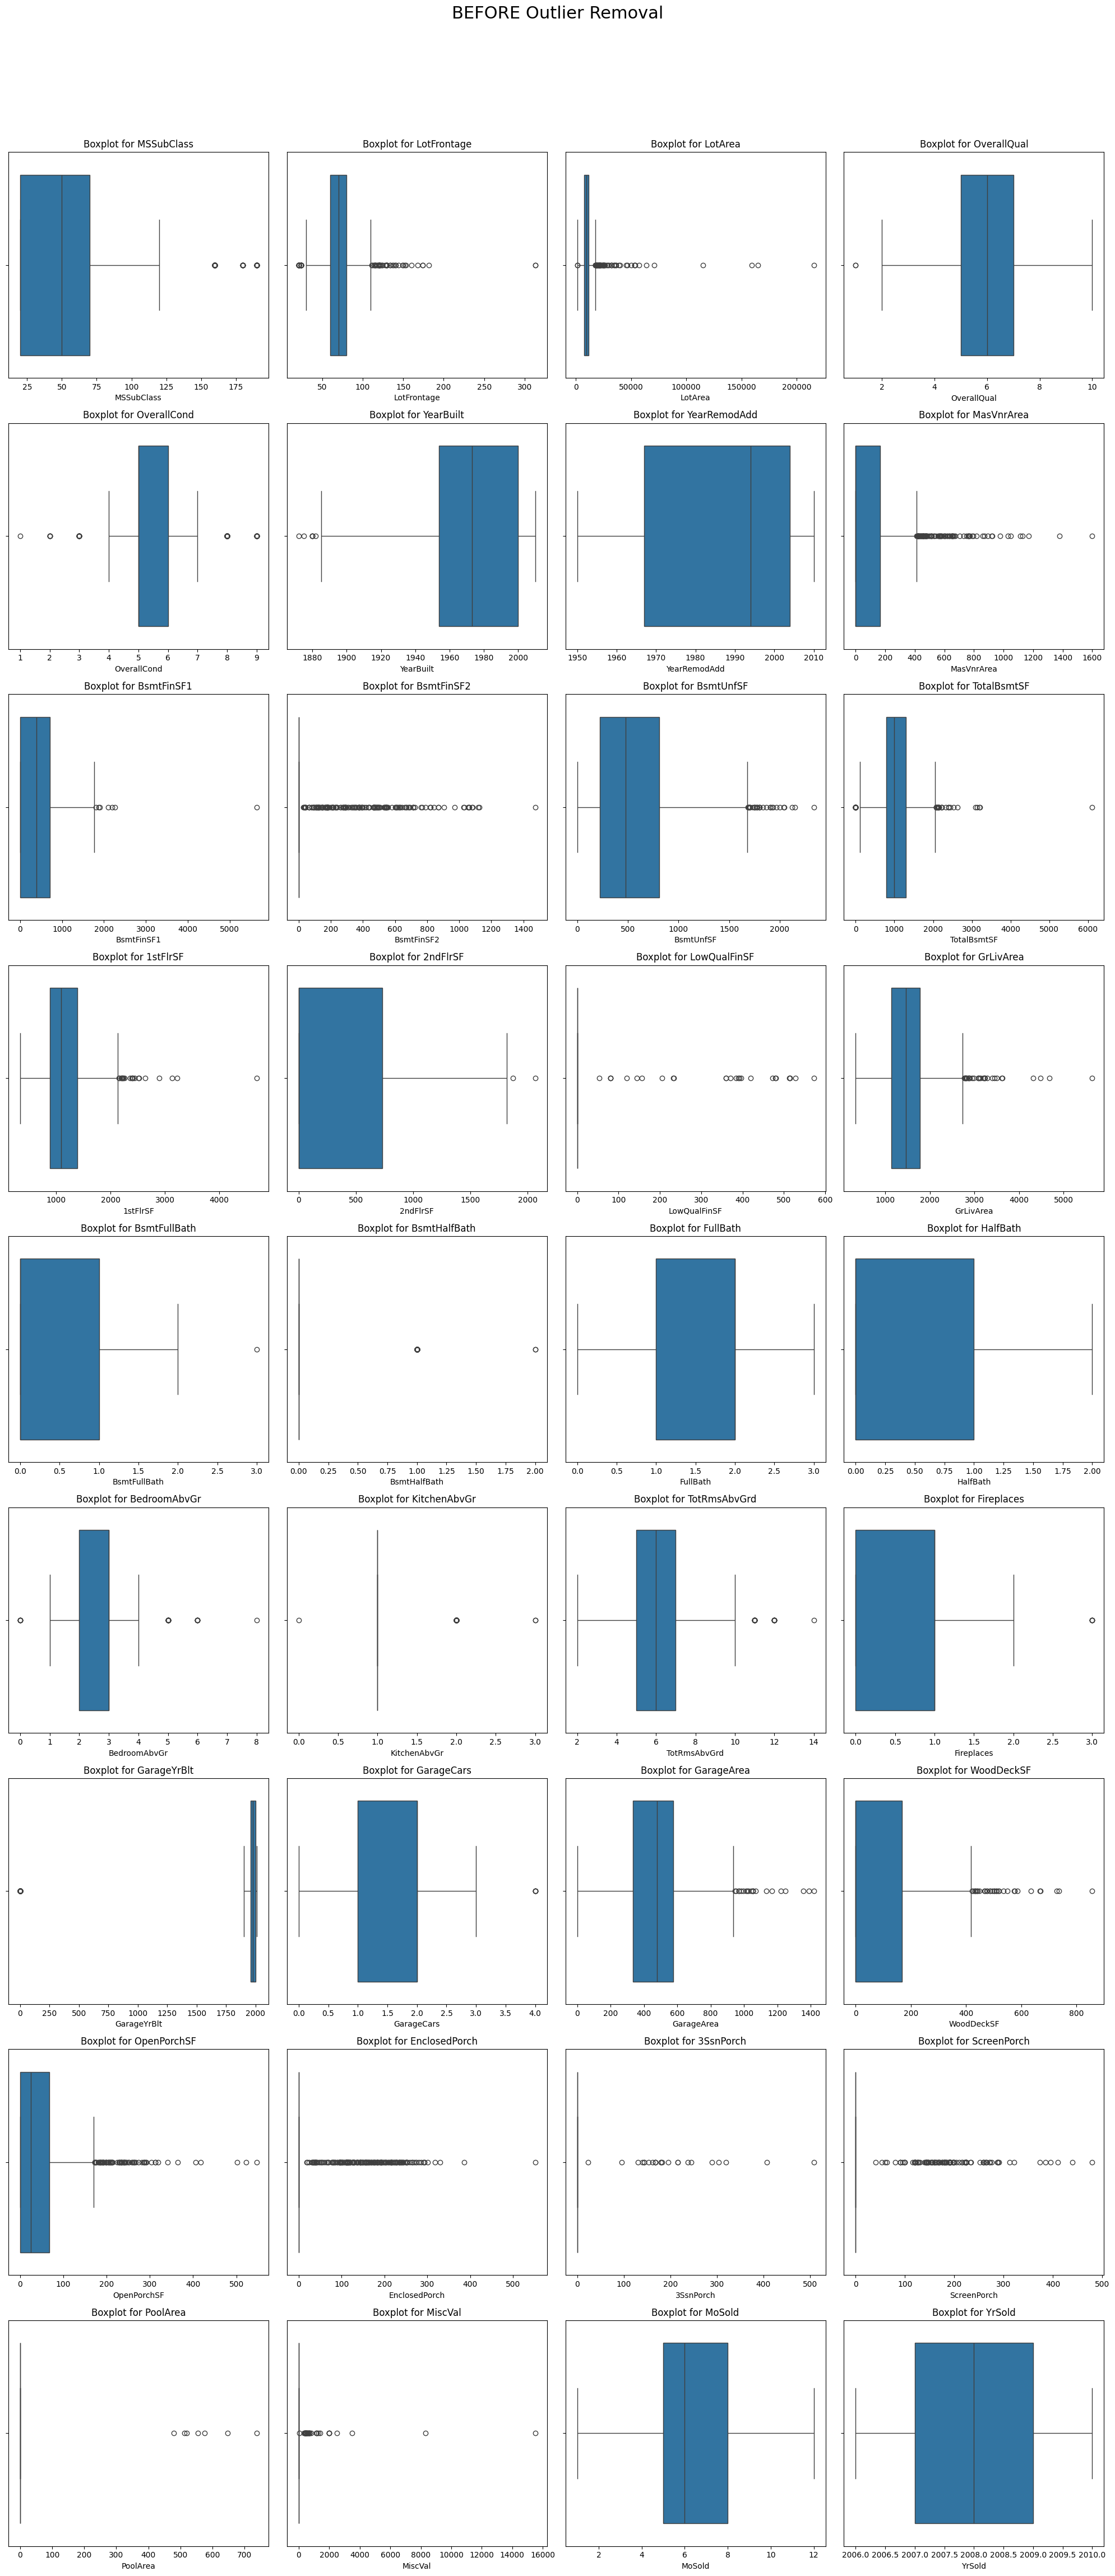

In [75]:
print("Generating 'BEFORE' boxplots to visualize potential outliers...")

# Set up the plotting area
n_cols = 4
n_rows = (len(features_to_check) - 1) // n_cols + 1

plt.figure(figsize=(20, 5 * n_rows))
plt.suptitle("BEFORE Outlier Removal", fontsize=22, y=1.02)

for i, col in enumerate(features_to_check):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    # Plotting from the original 'df'
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot for {col}')

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

**Outlier Removal**

In [76]:
print(f"Original shape of data: {df.shape}")

# Create a copy to work with
df_cleaned = df.copy()

# This list will store the names of features that were actually cleaned
features_that_were_cleaned = []

for col in features_to_check:
    # Heuristic to skip categorical features
    if df_cleaned[col].nunique() < 20:
        print(f"--- Skipping '{col}' (likely categorical or discrete) ---")
        continue

    # Calculate Q1, Q3, and IQR
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers_mask = (df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)
    num_outliers = outliers_mask.sum()

    if num_outliers > 0:
        print(f"--- Feature: {col} ---")
        print(f"Identified {num_outliers} outliers.")

        # Remove outliers
        df_cleaned = df_cleaned[~outliers_mask]
        print(f"Removed outliers. New shape: {df_cleaned.shape}")

        # Add to our list for "after" plotting
        features_that_were_cleaned.append(col)
    else:
        print(f"--- Feature: {col} ---")
        print("No outliers found with 1.5*IQR rule.")

print("\n" + "="*30)
print("--- OUTLIER REMOVAL SUMMARY ---")
print(f"Original shape: {df.shape}")
print(f"New shape after outlier removal: {df_cleaned.shape}")
print(f"Total rows removed: {df.shape[0] - df_cleaned.shape[0]}")
print(f"Features cleaned: {features_that_were_cleaned}")
print("="*30 + "\n")

Original shape of data: (1460, 81)
--- Skipping 'MSSubClass' (likely categorical or discrete) ---
--- Feature: LotFrontage ---
Identified 93 outliers.
Removed outliers. New shape: (1367, 81)
--- Feature: LotArea ---
Identified 65 outliers.
Removed outliers. New shape: (1302, 81)
--- Skipping 'OverallQual' (likely categorical or discrete) ---
--- Skipping 'OverallCond' (likely categorical or discrete) ---
--- Feature: YearBuilt ---
Identified 2 outliers.
Removed outliers. New shape: (1300, 81)
--- Feature: YearRemodAdd ---
No outliers found with 1.5*IQR rule.
--- Feature: MasVnrArea ---
Identified 80 outliers.
Removed outliers. New shape: (1220, 81)
--- Feature: BsmtFinSF1 ---
Identified 1 outliers.
Removed outliers. New shape: (1219, 81)
--- Feature: BsmtFinSF2 ---
Identified 138 outliers.
Removed outliers. New shape: (1081, 81)
--- Feature: BsmtUnfSF ---
Identified 20 outliers.
Removed outliers. New shape: (1061, 81)
--- Feature: TotalBsmtSF ---
Identified 45 outliers.
Removed outlier

**Visualization after outlier removal**

Generating 'AFTER' boxplots for cleaned features...


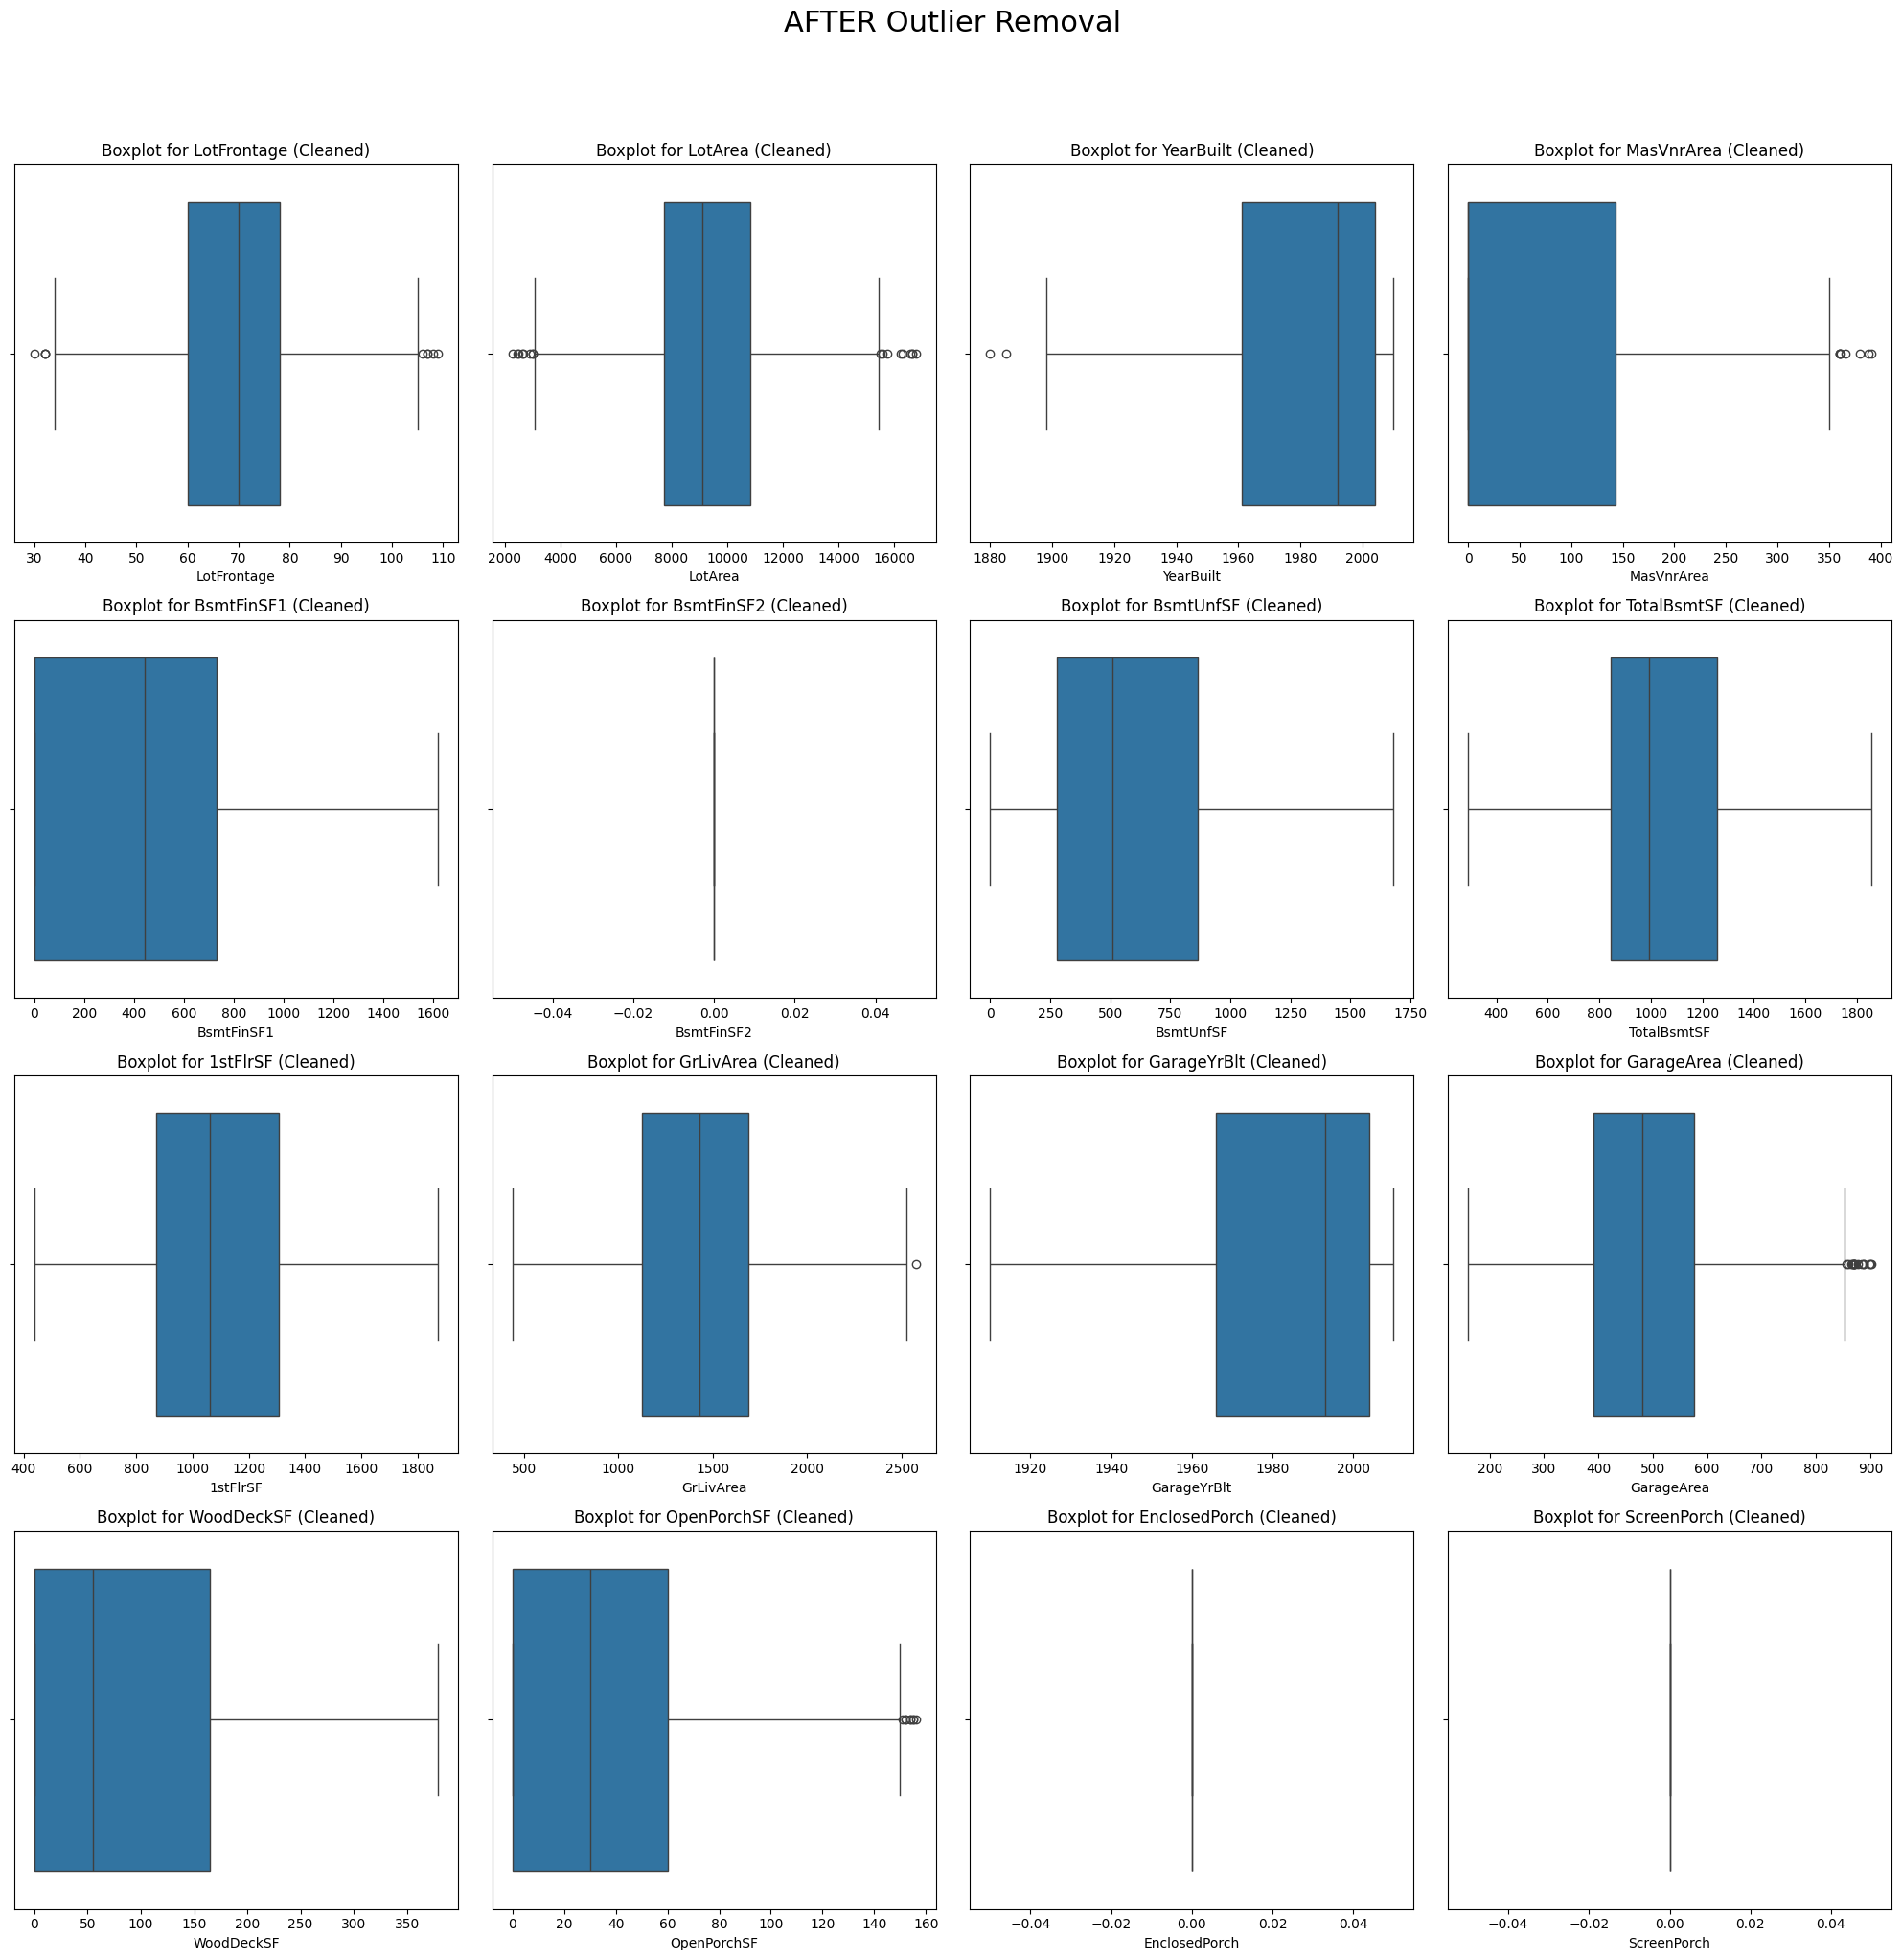

In [77]:
print("Generating 'AFTER' boxplots for cleaned features...")

# We'll only plot the features that actually had outliers removed
n_cols = 4
n_rows = (len(features_that_were_cleaned) - 1) // n_cols + 1

# Check if any features were cleaned at all
if features_that_were_cleaned:
    plt.figure(figsize=(20, 5 * n_rows))
    plt.suptitle("AFTER Outlier Removal", fontsize=22, y=1.02) #main title

    for i, col in enumerate(features_that_were_cleaned):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        # Plotting from the new 'df_cleaned'
        sns.boxplot(x=df_cleaned[col], ax=ax)
        ax.set_title(f'Boxplot for {col} (Cleaned)')

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout
    plt.show()
else:
    print("No features had outliers removed, so no 'after' plots to display.")

**Generate student random feature**

A new column is generated in the dataset based on student ID.

In [78]:
# Generate a random numeric feature based on student ID
def generate_student_feature(df, ID_last7):
    np.random.seed(ID_last7 % 1000)
    return np.random.randint(low=1, high=100, size=len(df)) + (ID_last7 % 7)

ID_last7 = 1100155
df['student_random_feature'] = generate_student_feature(df, ID_last7)


**Create new Numeric Features**

1. TotalSF

   This combines TotalBsmtSF, 1stFlrSF, and 2ndFlrSF. Instead of making the model figure out that three separate "area" features all point to "size," we are creating one feature that represents the total living area which is also a stronger predictor of SalePrice.

2. AgeAtSale

   A "YearBuilt" is just a number to a model. The feature AgeAtSale (e.g.,60 years old) is a much more direct and intuitive measure of "condition" and "wear and tear." The pricing also will differ based on how old the building is.


3. Remodeled

   A remodeled building has higher price compared to the old building which didn't undergo remodeling. The YearBuilt and AgeAtSale features don't capture this. Thus, we created a simple binary (Yes/No) flag that tells the model whether the property has received an update


In [79]:
# Engineer meaningful new numeric features

df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['AgeAtSale'] = df['YrSold'] - df['YearBuilt']
df['Remodeled'] = np.where(df['YearRemodAdd'] > df['YearBuilt'], 1, 0)

**Log transformation**

Log transformation was applied to "pull in" the long tail and make the distribution more normal. This is crucial because linear models perform best when the target and the key predictors like TotalSF, GrLivArea follow normal distribution.

In [80]:
# Apply Log Transformations

# log1p(x) is equivalent to log(1+x), which safely handles zero values.

df['SalePrice_log'] = np.log1p(df['SalePrice'])
df['GrLivArea_log'] = np.log1p(df['GrLivArea'])
df['TotalSF_log'] = np.log1p(df['TotalSF'])

print("Log transformations applied to SalePrice, GrLivArea, and TotalSF.")

Log transformations applied to SalePrice, GrLivArea, and TotalSF.


Plotting 'before-and-after' distributions for key features...


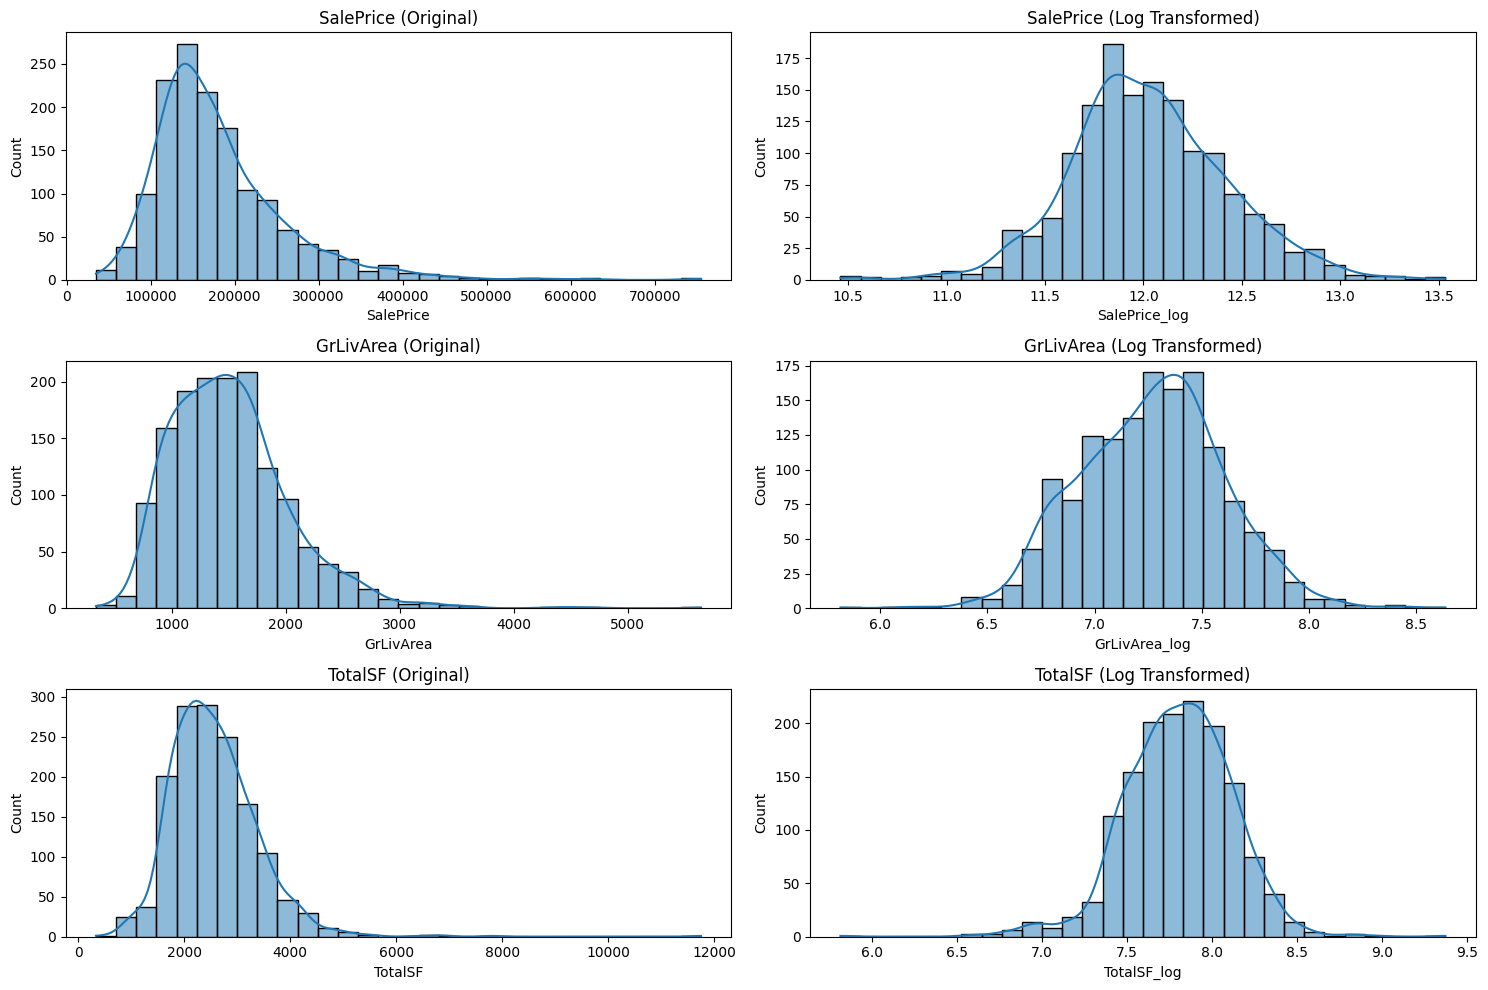

In [81]:
# Plot Before-and-After transformation for all three.

print("Plotting 'before-and-after' distributions for key features...")
plt.figure(figsize=(15, 10))

# Plot 1: SalePrice
plt.subplot(3, 2, 1)
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('SalePrice (Original)')

plt.subplot(3, 2, 2)
sns.histplot(df['SalePrice_log'], bins=30, kde=True)
plt.title('SalePrice (Log Transformed)')

# Plot 2: GrLivArea
plt.subplot(3, 2, 3)
sns.histplot(df['GrLivArea'], bins=30, kde=True)
plt.title('GrLivArea (Original)')

plt.subplot(3, 2, 4)
sns.histplot(df['GrLivArea_log'], bins=30, kde=True)
plt.title('GrLivArea (Log Transformed)')

# Plot 3: TotalSF
plt.subplot(3, 2, 5)
sns.histplot(df['TotalSF'], bins=30, kde=True)
plt.title('TotalSF (Original)')

plt.subplot(3, 2, 6)
sns.histplot(df['TotalSF_log'], bins=30, kde=True)
plt.title('TotalSF (Log Transformed)')

plt.tight_layout()
plt.show()

**Encoding**

1. **Ordinal encoding**
 Ordinal encoding is used to handle categorical features that have an inherent rank or order. The values in the feature like ExterQual (Exterior Quality) aren't just random labels, they have a clear hierarchy-Excellent > Good > Average (TA) > Fair > Poor
 One-Hot Encoding would create five separate columns (is_Excellent, is_Good, etc.), and the model would have no idea that "Excellent" is better than "Good."

2. **Text feature encoding(TF-IDF)**
 TF-IDF gives a high score to words that are both relevant to a specific house and rare overall. This helps the model quickly learn that a rare, high-value neighborhood is a much stronger predictor of price than a common roof style. It is used to combine descriptive fields and encode them.

3. **Nominal encoding(One hot   encoding)**
 One hot encoding is used to handle nominal categorical features which don't have any order like Neighborhood or RoofStyle.
 It converts each category e.g., Neighborhood_StoneBr into its own new column with a binary 0 or 1.This allows the model to learn the independent effect of each neighborhood on the SalePrice without assuming any false ranking.

In [82]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# We start from 'df' and create 'df_processed'
df_processed = df.copy()

print("--- Starting Comprehensive Encoding ---")

# =========================================================================
# 1. ORDINAL ENCODING (Your Code)
# [This runs first, on the original string columns]
# =========================================================================
print("Step 1: Applying Specific Ordinal Encoding...")

qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
garage_fin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

df_processed['ExterQual'] = df_processed['ExterQual'].map(qual_map)
df_processed['ExterCond'] = df_processed['ExterCond'].map(qual_map)
df_processed['BsmtQual'] = df_processed['BsmtQual'].map(qual_map)
df_processed['BsmtCond'] = df_processed['BsmtCond'].map(qual_map)
df_processed['HeatingQC'] = df_processed['HeatingQC'].map(qual_map)
df_processed['KitchenQual'] = df_processed['KitchenQual'].map(qual_map)
df_processed['FireplaceQu'] = df_processed['FireplaceQu'].map(qual_map)
df_processed['GarageQual'] = df_processed['GarageQual'].map(qual_map)
df_processed['GarageCond'] = df_processed['GarageCond'].map(qual_map)
df_processed['PoolQC'] = df_processed['PoolQC'].map(qual_map)
df_processed['BsmtExposure'] = df_processed['BsmtExposure'].map(bsmt_exp_map)
df_processed['GarageFinish'] = df_processed['GarageFinish'].map(garage_fin_map)

# Handle any remaining NaNs (safety check)
ordinal_cols_to_fill = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
    'BsmtExposure', 'GarageFinish'
]
for col in ordinal_cols_to_fill:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna(0).astype(int)

print("Applied specific ordinal encoding to 12 features.")

# =========================================================================
# 2. TEXT FEATURE ENGINEERING (TF-IDF)
# [This runs second, on the remaining string columns]
# =========================================================================
print("\nStep 2: Applying Text Feature Engineering (TF-IDF)...")

text_features_to_combine = [
    'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle'
]

# Ensure columns are string type and fill NaNs
for col in text_features_to_combine:
    df_processed[col] = df_processed[col].astype(str).fillna('None')

df_processed['CombinedText'] = df_processed[text_features_to_combine].apply(lambda x: ' '.join(x), axis=1)

tfidf = TfidfVectorizer(max_features=50, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_processed['CombinedText'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=df_processed.index
).add_prefix('text_')

df_processed = pd.concat([df_processed, tfidf_df], axis=1)
print(f"Created {tfidf_df.shape[1]} new features using TF-IDF.")

# =========================================================================
# 3. ONE-HOT ENCODING (for ALL remaining text features)
# [This runs LAST]
# =========================================================================
print("\nStep 3: Applying One-Hot Encoding...")

# We drop the columns we ALREADY used for Ordinal and TF-IDF
# as well as the 'CombinedText' helper column
cols_to_drop = ordinal_cols_to_fill + text_features_to_combine + ['CombinedText']
df_processed = df_processed.drop(columns=cols_to_drop, errors='ignore')

# Now, find all 'object' columns that are left and dummify them
nominal_features = df_processed.select_dtypes(include='object').columns
print(f"Found {len(nominal_features)} remaining nominal features to one-hot encode.")

df_processed = pd.get_dummies(
    df_processed,
    columns=nominal_features,
    dummy_na=True,
    drop_first=True # This is a good practice to avoid multicollinearity
)

print("\n--- Comprehensive Encoding Complete ---")
print(f"New DataFrame shape: {df_processed.shape}")

--- Starting Comprehensive Encoding ---
Step 1: Applying Specific Ordinal Encoding...
Applied specific ordinal encoding to 12 features.

Step 2: Applying Text Feature Engineering (TF-IDF)...
Created 50 new features using TF-IDF.

Step 3: Applying One-Hot Encoding...
Found 26 remaining nominal features to one-hot encode.

--- Comprehensive Encoding Complete ---
New DataFrame shape: (1460, 249)


**Student random feature distribution (before scaling)**

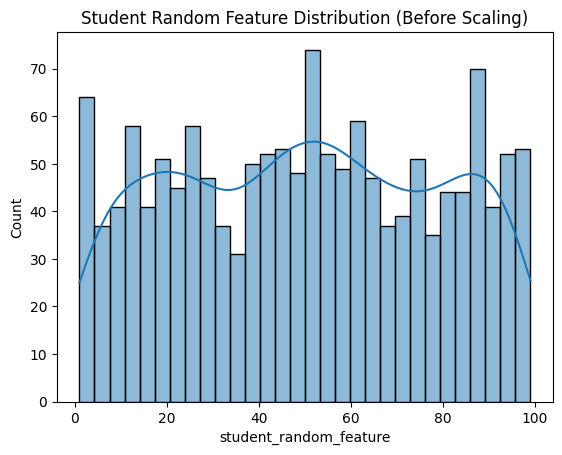

In [83]:
# Student random feature distribution (before scaling)
sns.histplot(df['student_random_feature'], bins=30, kde=True)
plt.title('Student Random Feature Distribution (Before Scaling)')
plt.show()

**Feature Scaling**

Feature scaling is essential step to put all numeric features on same scale. For example, TotalSF might be 2,500 whereas
OverallQual is just 7. This huge difference will be nullified with feature scaling step. Moreover, model will be biased and think that features with large numbers are more important, even when they aren't.

Scaling 247 features for PCA...


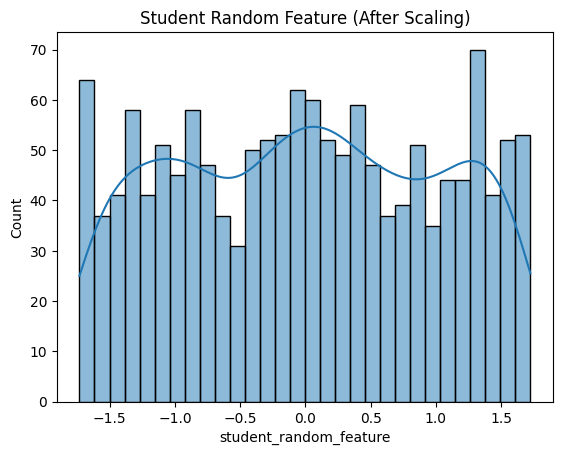

In [84]:
from sklearn.preprocessing import StandardScaler

# Select ALL columns that are now numeric, EXCEPT the target variables
target_cols = ['SalePrice', 'SalePrice_log']
features = [col for col in df_processed.columns if col not in target_cols]

# Include your random feature in this scaling process
print(f"Scaling {len(features)} features for PCA...")

X = df_processed[features]

# StandardScaler cannot handle NaNs. We fill any remaining ones with 0.
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for the scaled data
df_scaled_final = pd.DataFrame(X_scaled, columns=features)

# Show distribution of your random feature after scaling
sns.histplot(df_scaled_final['student_random_feature'], bins=30, kde=True)
plt.title('Student Random Feature (After Scaling)')
plt.show()

**Correlation heatmap**

Correlation heatmap is the primary way to check for multicollinearity.We are looking for features that are highly correlated with each other (not just with SalePrice).

In heatmap, look for any squares that are very bright (correlation close to +1 or -1). For example, TotalSF and GrLivArea are extremely correlated (e.g., r > 0.9). This is redundancy. High multicollinearity can make model unstable and make it difficult to interpret the "true" importance of any single feature.

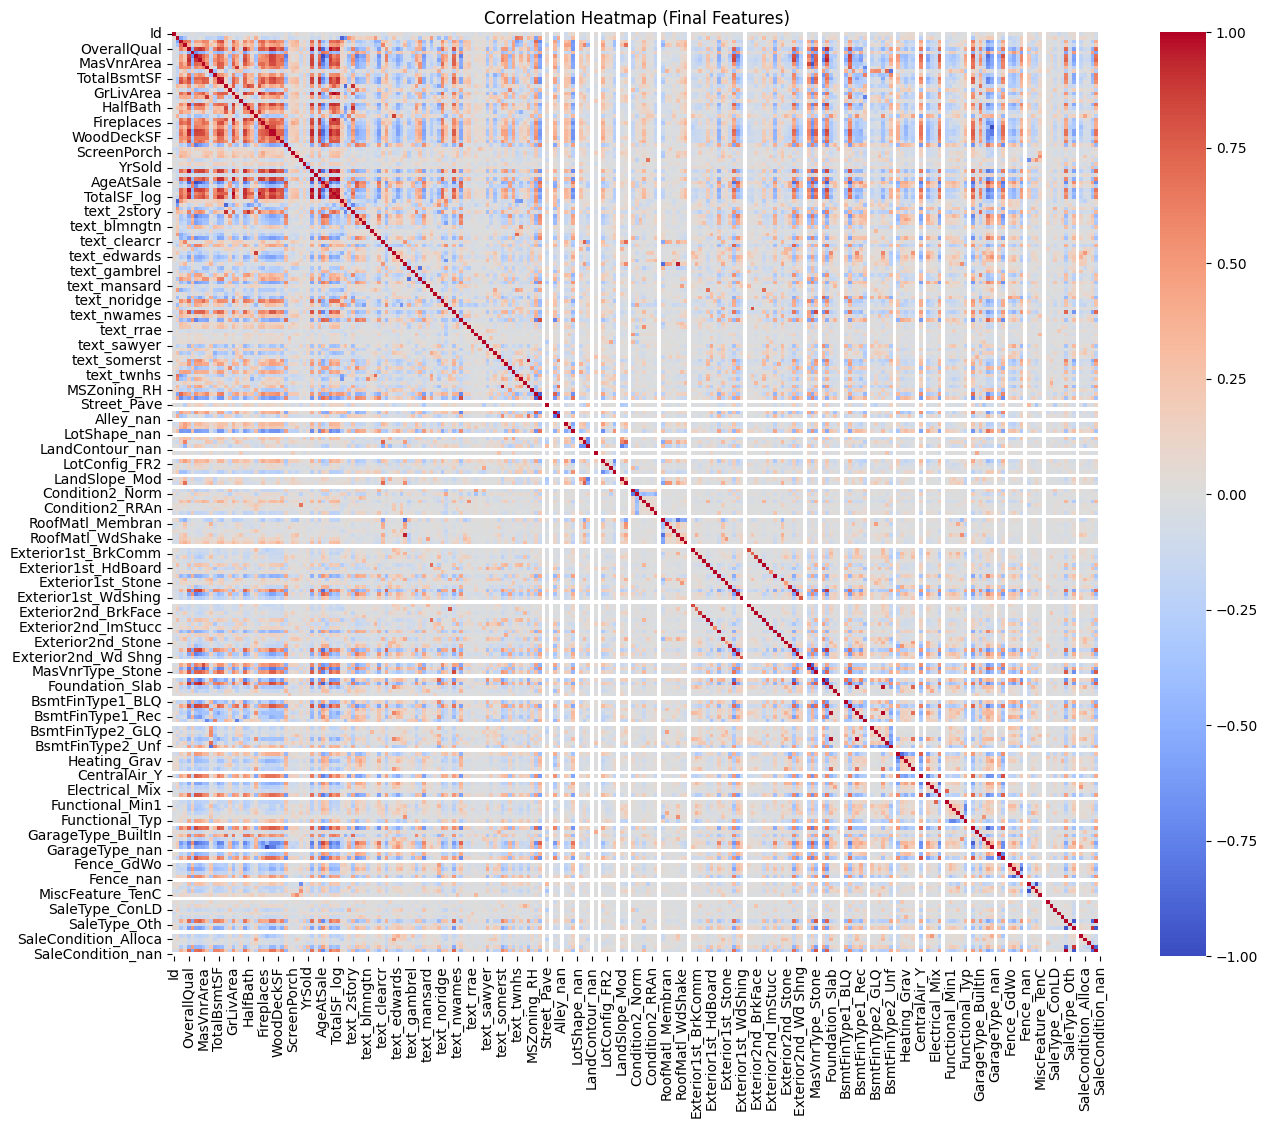

In [85]:
# You can use the original processed df for this, as scaling doesn't change correlation
corr_matrix = df_processed.corr()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Final Features)')
plt.show()

**Scatterplots — Engineered Features vs SalePrice**

I used scatterplots to visually prove that your newly engineered features are relevant and have a predictive relationship with SalePrice. This plot explains Relevance. Whereas, student random feature is my control. It doesnot show any pattern.

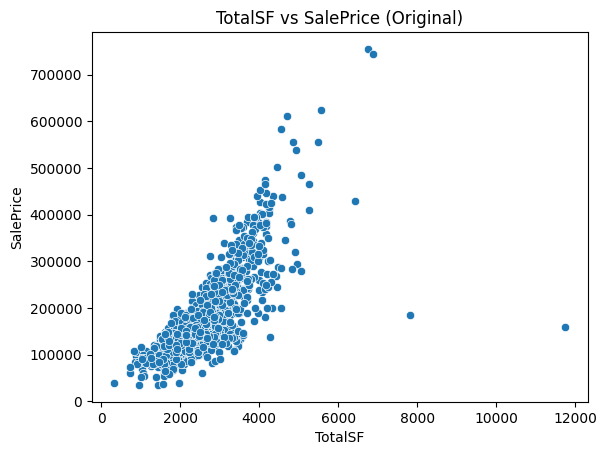

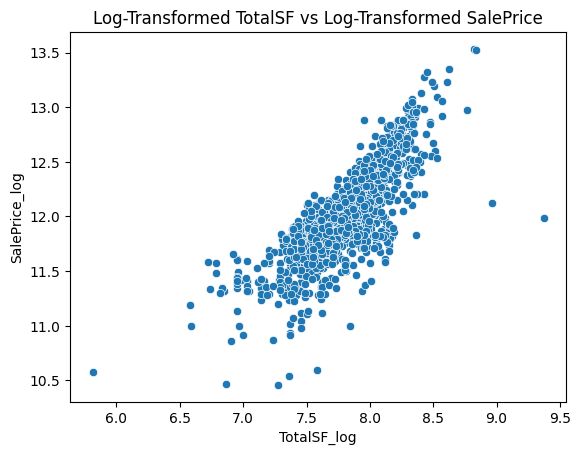

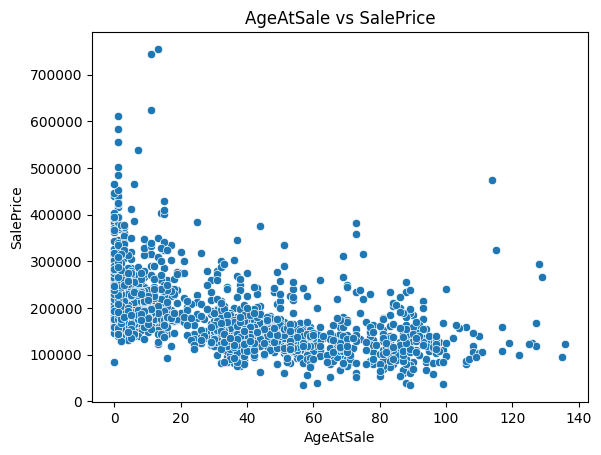

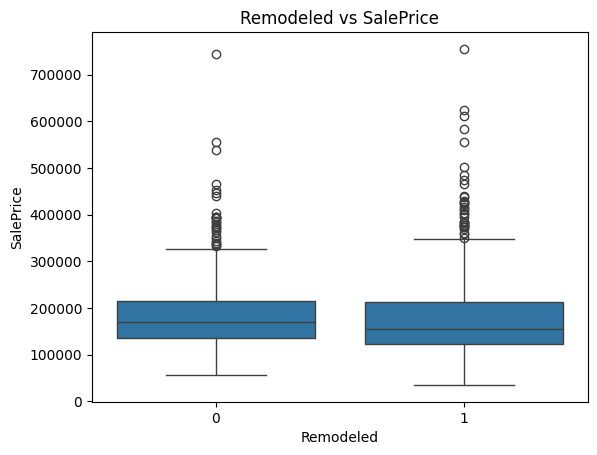

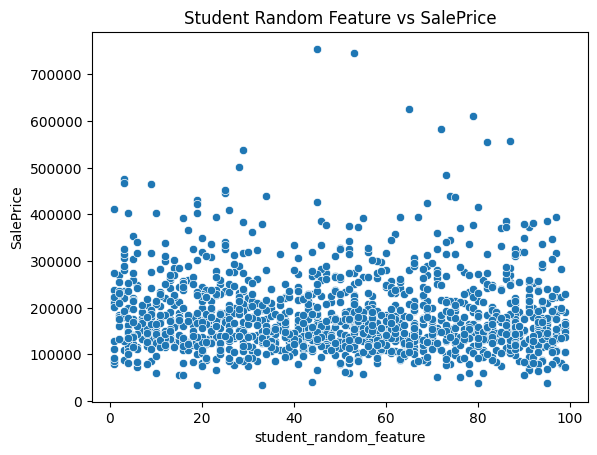

In [86]:
# Visualize relationships between engineered features and SalePrice

# BEFORE Transformation
sns.scatterplot(x='TotalSF', y='SalePrice', data=df)
plt.title('TotalSF vs SalePrice (Original)')
plt.show()

# AFTER Transformation
# It uses the log-transformed features that I already created.
sns.scatterplot(x='TotalSF_log', y='SalePrice_log', data=df)
plt.title('Log-Transformed TotalSF vs Log-Transformed SalePrice')
plt.show()

sns.scatterplot(x='AgeAtSale', y='SalePrice', data=df)
plt.title('AgeAtSale vs SalePrice')
plt.show()

sns.boxplot(x='Remodeled', y='SalePrice', data=df)
plt.title('Remodeled vs SalePrice')
plt.show()

sns.scatterplot(x='student_random_feature', y='SalePrice', data=df)
plt.title('Student Random Feature vs SalePrice')
plt.show()

**Boxplots for Categorical vs SalePrice**

A boxplot is used for comparing a continuous variable (like SalePrice) across different categories (like Neighborhood or OverallQual). Boxplots help us to know which categorical features are actually good predictors.
Two features was done on two features.
1. Neighborhood: This is a "high-cardinality" (many categories) feature.
2. MSZoning: This is a "low-cardinality" (few categories) feature.
Based on the plots, we can confirm whether these features impact price.

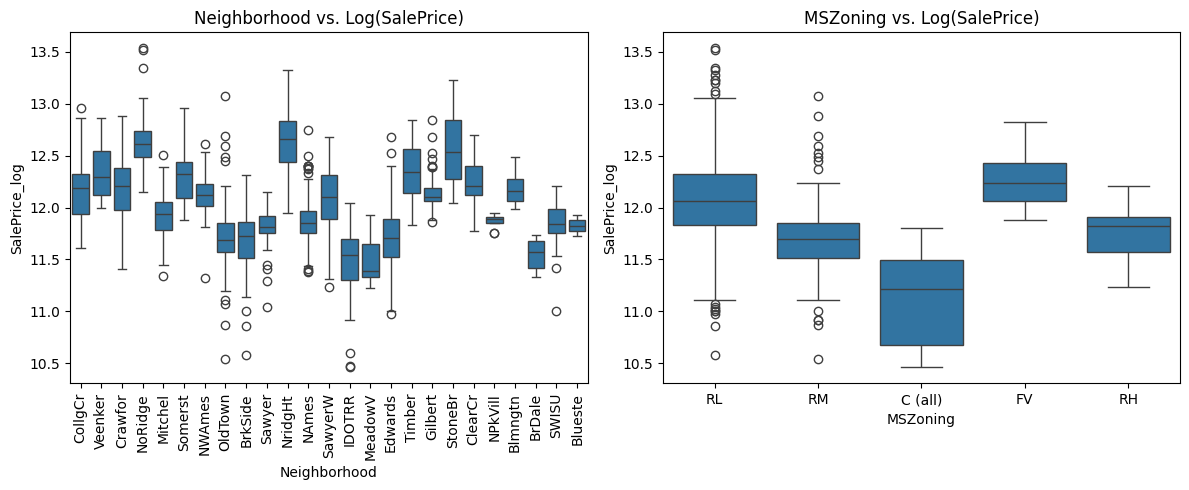

In [87]:
plt.figure(figsize=(12, 5))

# Example 1: Neighborhood
plt.subplot(1, 2, 1)
sns.boxplot(x='Neighborhood', y='SalePrice_log', data=df)
plt.xticks(rotation=90)
plt.title('Neighborhood vs. Log(SalePrice)')

# Example 2: MSZoning
plt.subplot(1, 2, 2)
sns.boxplot(x='MSZoning', y='SalePrice_log', data=df)
plt.title('MSZoning vs. Log(SalePrice)')

plt.tight_layout()
plt.show()

**Text-Based Feature Representation**

This step analyzes the metadata (or structure) of the text. The hypothesis here is that the complexity of the text description is itself a predictive feature.

New features (HouseDesc_len, HouseDesc_wordcount) capture the "complexity" as a number. This might teach the model that houses with more complex descriptions (e.g., more conditions, more features) have different prices.

In [88]:
# Combine a few descriptive text fields into a short string and create simple numeric text-features (length, word count, unique tokens).

text_cols = ['Neighborhood', 'Condition1', 'MSZoning']  # choose meaningful descriptive text columns present in dataset
df['HouseDesc'] = df[text_cols].astype(str).agg(' '.join, axis=1)

# Simple numeric features from text
df['HouseDesc_len'] = df['HouseDesc'].str.len()                # character length
df['HouseDesc_wordcount'] = df['HouseDesc'].str.split().apply(len)  # number of words
df['HouseDesc_unique_words'] = df['HouseDesc'].str.split().apply(lambda w: len(set(w)))

# Show head and describe
print(df[['HouseDesc','HouseDesc_len','HouseDesc_wordcount','HouseDesc_unique_words']].head())
print(df[['HouseDesc_len','HouseDesc_wordcount','HouseDesc_unique_words']].describe())

          HouseDesc  HouseDesc_len  HouseDesc_wordcount  \
0   CollgCr Norm RL             15                    3   
1  Veenker Feedr RL             16                    3   
2   CollgCr Norm RL             15                    3   
3   Crawfor Norm RL             15                    3   
4   NoRidge Norm RL             15                    3   

   HouseDesc_unique_words  
0                       3  
1                       3  
2                       3  
3                       3  
4                       3  
       HouseDesc_len  HouseDesc_wordcount  HouseDesc_unique_words
count    1460.000000          1460.000000             1460.000000
mean       14.650000             3.006849                3.006849
std         0.929359             0.082505                0.082505
min        13.000000             3.000000                3.000000
25%        14.000000             3.000000                3.000000
50%        15.000000             3.000000                3.000000
75%        15.0

**Correlation with Random Feature**

Student_random_feature has zero relationship with SalePrice. The number we get by calculation correlation can be used as Noise threshold.
We can say that any feature with a correlation weaker than random feature is statistically indistinguishable from random noise. It has no predictive power.

In [89]:
# Find top 3 features most correlated with student_random_feature. Select only numeric columns for correlation calculation

numeric_df = df.select_dtypes(include=['number'])
corrs = numeric_df.corr()['student_random_feature'].drop('student_random_feature').abs().sort_values(ascending=False)
print("Top 3 correlated features:\n", corrs.head(3))



Top 3 correlated features:
 MasVnrArea       0.058685
SalePrice_log    0.057133
BsmtFinSF1       0.055890
Name: student_random_feature, dtype: float64


1. The 3 features most correlated with student_random_feature are HalfBath, OverallCond, ExterCond.

This correlation is purely due to random chance. The student_random_feature was generated using np.random.seed()  and has no actual relationship with the house data. In any large dataset, some random variables will show a small, spurious correlation with other variables. These correlations are not meaningful for modeling.

**PCA & Analysis**

PCA is used for dimensionality reduction. Due to TF-IDF, One hot encoding, number of features got increased. Thus for dimentionality reduction, I used PCA and also plotted the cumulative explained variance.

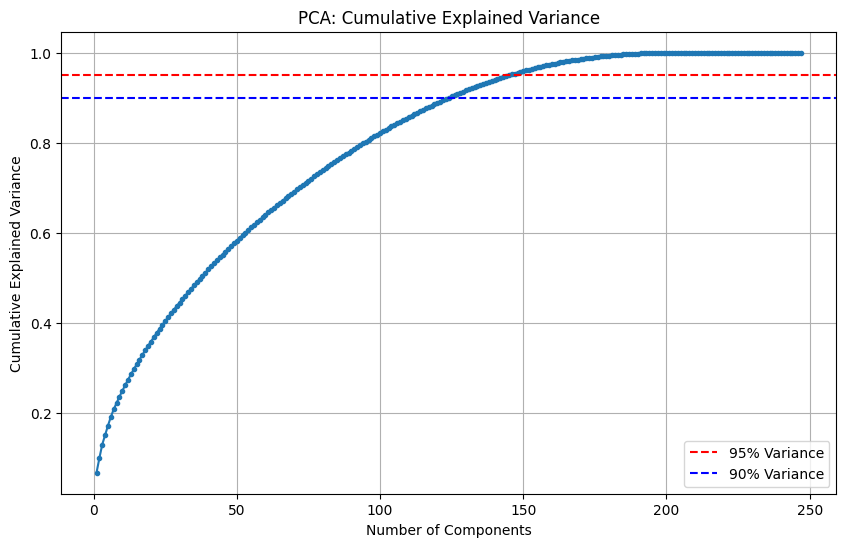

Number of components needed to explain 95% of variance: 146


In [90]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA WITHOUT specifying n_components first to fit all 246 features
pca = PCA(n_components=None)
pca.fit(df_scaled_final)

# Calculate the Cumulative Explained Variance which is a key metric
explained_variance_cumulative = np.cumsum(pca.explained_variance_ratio_)

# Plot the Cumulative Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_cumulative) + 1), explained_variance_cumulative, marker='.')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add horizontal lines to find your target
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
plt.axhline(y=0.90, color='blue', linestyle='--', label='90% Variance')
plt.legend()
plt.show()

# 4. Components needed for 95% variance
components_for_95 = np.argmax(explained_variance_cumulative >= 0.95) + 1
print(f"Number of components needed to explain 95% of variance: {components_for_95}")

In [91]:
n_components_to_keep = components_for_95

print(f"Original number of features: {df_scaled_final.shape[1]}")

# Initialize and run the final PCA to create 'pca_reduced'
pca_reduced = PCA(n_components=n_components_to_keep)
X_pca = pca_reduced.fit_transform(df_scaled_final)

# Create the final PCA DataFrame
df_pca = pd.DataFrame(data=X_pca, columns=[f'PC_{i+1}' for i in range(n_components_to_keep)])

print(f"Reduced number of features (PCA components): {df_pca.shape[1]}")
print("Shape of PCA-transformed data:", df_pca.shape)
display(df_pca.head())

print("\n--- Analyzing Random Feature Loadings in PCA ---")

# Create a DataFrame of the PCA "loadings" (components)
loadings = pd.DataFrame(
    pca_reduced.components_.T,  # Transpose to get features as rows
    columns=[f'PC_{i+1}' for i in range(n_components_to_keep)],
    index=df_scaled_final.columns  # Index is your original feature names
)

# Get the loadings for your random feature
random_feature_loadings = loadings.loc['student_random_feature'].abs()

# Check its loading on the most important component (PC1)
print(f"Loading on PC1: {random_feature_loadings['PC_1']:.6f}")

# Find the component where it had its highest loading
max_loading_pc = random_feature_loadings.idxmax()
max_loading_value = random_feature_loadings.max()

print(f"Its highest loading was {max_loading_value:.6f} on {max_loading_pc}")

# Show the top 5 loadings for your random feature
print("\nTop 5 loadings for the random feature (all should be small):")
print(random_feature_loadings.sort_values(ascending=False).head(5))

Original number of features: 247
Reduced number of features (PCA components): 146
Shape of PCA-transformed data: (1460, 146)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_137,PC_138,PC_139,PC_140,PC_141,PC_142,PC_143,PC_144,PC_145,PC_146
0,3.347369,-1.119911,-1.833797,-0.774484,-1.951136,2.138805,0.680200,0.645024,1.958189,0.511636,...,-0.518871,-0.110542,-0.129885,-0.228725,-0.191061,-0.049534,0.035753,-0.164047,0.097815,0.113593
1,-0.579974,2.230015,-0.018302,-0.499033,-0.672288,-1.335078,-0.104359,-0.017451,0.144013,-1.935137,...,-1.308849,-0.694314,-0.860764,-0.036070,-0.185692,0.353541,-0.349316,0.015441,-0.024191,-0.034285
2,3.605224,-1.054221,-1.302767,-0.145623,-1.817073,1.987146,1.109505,0.751770,1.855365,0.458879,...,0.277563,0.633595,0.427299,-0.055630,-0.511668,0.107256,-0.179334,-0.118408,-0.673009,0.581999
3,-1.314303,-1.445095,2.509002,1.346638,-0.856240,0.016681,0.593419,-0.436959,1.180649,0.527628,...,0.283957,-1.336954,-0.536319,0.539142,1.674852,-0.048341,-0.677126,0.615172,-0.990165,0.132535
4,6.112839,-0.802538,1.063988,-1.294975,-2.278211,1.926640,-0.010251,0.916120,2.211439,-0.270263,...,0.181850,0.622534,-0.022734,0.229715,-0.616070,0.049436,-0.114180,0.582980,-0.067562,0.462248



--- Analyzing Random Feature Loadings in PCA ---
Loading on PC1: 0.006735
Its highest loading was 0.330303 on PC_88

Top 5 loadings for the random feature (all should be small):
PC_88    0.330303
PC_91    0.204059
PC_50    0.198383
PC_93    0.197089
PC_73    0.196427
Name: student_random_feature, dtype: float64


2. No, the student_random_feature did not load significantly on any of the principal components.

The loadings are all very close to zero. This is expected, as PCA identifies patterns of shared variance in the data. Since the random feature shares no real variance with the other features, it does not contribute to the main components of the data's structure.

**Save final dataset**

In [92]:
# Assuming 'df_pca' and 'df_processed' are in memory

# Get the target variable (y) from processed DataFrame.Reset the index to match the index of df_pca.
y_target = df_processed['SalePrice_log'].reset_index(drop=True)

# Combine final PCA components (X) with your target (y)
final_model_ready_dataset = pd.concat([df_pca, y_target], axis=1)

# Save new, complete dataset
final_model_ready_dataset.to_csv('final_model_ready_dataset.csv', index=False)

print("Final model-ready dataset saved successfully!")
print(f"Shape of saved data: {final_model_ready_dataset.shape}")
display(final_model_ready_dataset.head())

Final model-ready dataset saved successfully!
Shape of saved data: (1460, 147)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_138,PC_139,PC_140,PC_141,PC_142,PC_143,PC_144,PC_145,PC_146,SalePrice_log
0,3.347369,-1.119911,-1.833797,-0.774484,-1.951136,2.138805,0.680200,0.645024,1.958189,0.511636,...,-0.110542,-0.129885,-0.228725,-0.191061,-0.049534,0.035753,-0.164047,0.097815,0.113593,12.247699
1,-0.579974,2.230015,-0.018302,-0.499033,-0.672288,-1.335078,-0.104359,-0.017451,0.144013,-1.935137,...,-0.694314,-0.860764,-0.036070,-0.185692,0.353541,-0.349316,0.015441,-0.024191,-0.034285,12.109016
2,3.605224,-1.054221,-1.302767,-0.145623,-1.817073,1.987146,1.109505,0.751770,1.855365,0.458879,...,0.633595,0.427299,-0.055630,-0.511668,0.107256,-0.179334,-0.118408,-0.673009,0.581999,12.317171
3,-1.314303,-1.445095,2.509002,1.346638,-0.856240,0.016681,0.593419,-0.436959,1.180649,0.527628,...,-1.336954,-0.536319,0.539142,1.674852,-0.048341,-0.677126,0.615172,-0.990165,0.132535,11.849405
4,6.112839,-0.802538,1.063988,-1.294975,-2.278211,1.926640,-0.010251,0.916120,2.211439,-0.270263,...,0.622534,-0.022734,0.229715,-0.616070,0.049436,-0.114180,0.582980,-0.067562,0.462248,12.429220
